# Predictive modeling

## EDA

### Trajectory clustering experiments

#### Dynamic time warping with K-means on whole patient trajectory weight and BC data - MVP1, 17Sept26

GOAL
- to identify weight loss and body composition change trajectory clusters

DATAPREP
- whole patient trajectories used (unit of analysis determined by patient_id)
- instant dropouts excluded - dtw needs serial data - but clinically, they constitute the 0th cluster that should be characterized
- patients with missing BC excluded - dtw needs complete data - missing data would need imputation if we want to use all
- ! most adherent patients excluded: patients with over 50 weigh-ins excluded from the first run, because it slows down early iteration - but these patients are valuable, the top 10% of patients have an average of 107 weigh-ins, and the top has 752
- tensor formatting: uneven patient histories are zero-padded with NaNs and pivoted into a 3D tensor

ML ARCHITECTURE
- algorithm: TimeSeriesKMeans with dynamic time warping. DTW aligns sequence shapes elastically, neutralizing irregular gaps between weigh-ins. It natively ignores NaN padding. 
- k selection: k 2-7 evaluated, best selected with a silhouette score only. But, silhouette evaluation is executed on a random subsample of n max = 1000 per cluster, because it would take too much time on the 14-15k samples

VISUALIZATION
- model-derived: DTW barycenters / raw mathematical cluster centers plotted around warped time steps to emphasize the model-derived SHAPE of the weight loss response
- raw, LOWESS-smoothed: per cluster, raw change trajectories are plotted, to see if clusters actually look coherent in real life, or only their warped trajectory shape

c:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\p4_dir\.venv\Lib\site-packages\tslearn\bases\bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


Loading data from C:/Users/miksa.henkrich/OneDrive - IMDEANU/Escritorio/PNK/p4_dir/dbs/pnk_db2_filtered.sqlite...
Initial data: 396210 rows, 14515 patients.
After dropping missing values: 360306 rows.
After enforcing >=2 timepoints: 359638 rows, 13770 patients remaining.
After capping at 50 timepoints: 202865 rows, 12150 patients.
Calculating days from baseline for time axis...
Calculating percentage change from baseline...
Reshaping data for tslearn...
Dataset reshaped successfully. Shape: (12150, 50, 3)
Starting DTW KMeans search for k in range 2-7...

--- Fitting k=2 ---
Computing silhouette score on subset of 2000 trajectories...
k=2 | Silhouette Score: 0.4892

--- Fitting k=3 ---
Computing silhouette score on subset of 3000 trajectories...
k=3 | Silhouette Score: 0.3749

--- Fitting k=4 ---
Computing silhouette score on subset of 3358 trajectories...
k=4 | Silhouette Score: 0.3123

--- Fitting k=5 ---
Computing silhouette score on subset of 3753 trajectories...
k=5 | Silhouette Sc

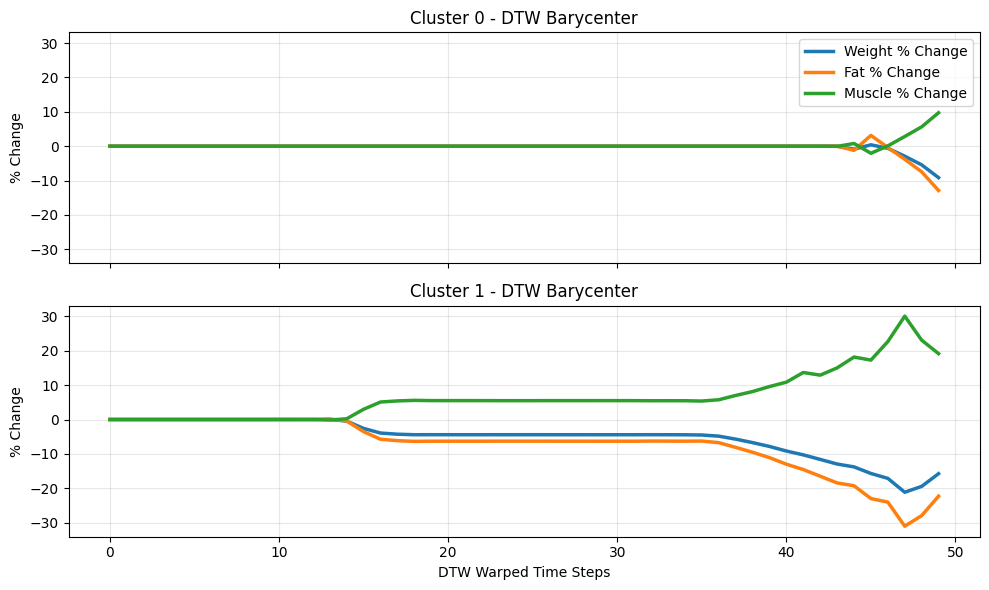

Saved LOWESS plot to C:/Users/miksa.henkrich/OneDrive - IMDEANU/Escritorio/PNK/p4_dir/out/lowess_trajectories.png


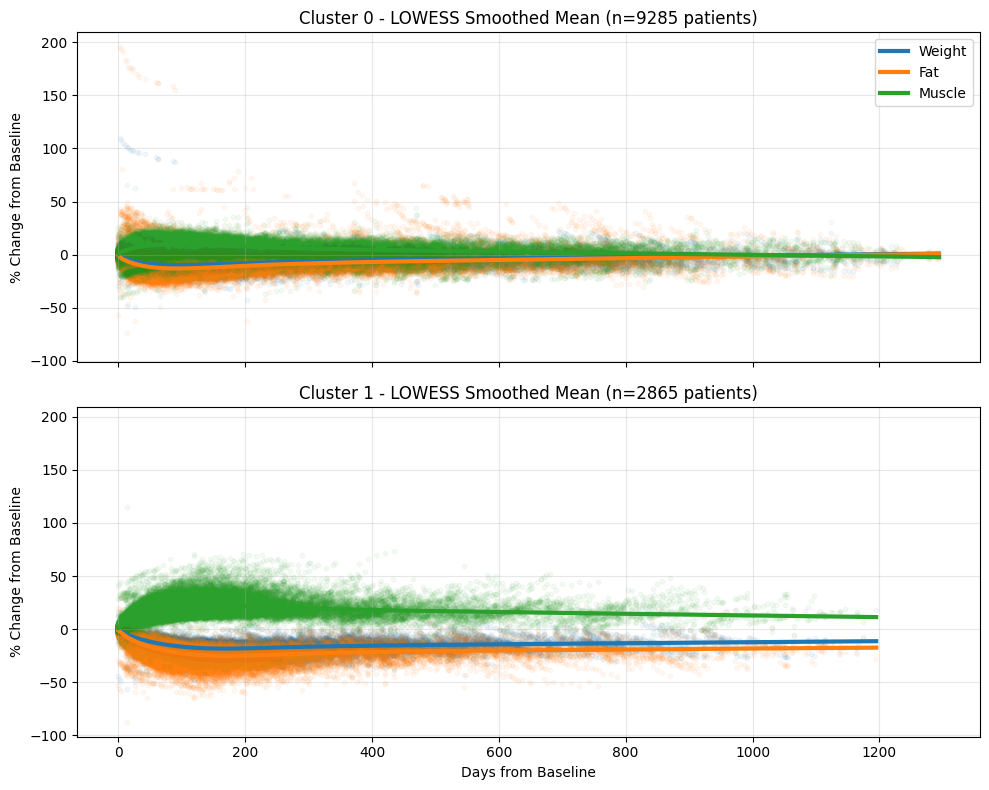

In [1]:
import sys
# Ensure the scripts directory is in path so we can import the module
sys.path.append('scripts')
import mdtw_mvp1

# ==========================================
# 1. CONFIGURATION
# ==========================================
SOURCE_DB_PATH = "C:/Users/miksa.henkrich/OneDrive - IMDEANU/Escritorio/PNK/p4_dir/dbs/pnk_db2_filtered.sqlite"
OUTPUT_DB_PATH = "C:/Users/miksa.henkrich/OneDrive - IMDEANU/Escritorio/PNK/p4_dir/out/out_db.sqlite"
OUTPUT_TABLE_NAME = "dtw_mvp1_cluster_labels"

BARYCENTER_PLOT_PATH = "C:/Users/miksa.henkrich/OneDrive - IMDEANU/Escritorio/PNK/p4_dir/out/dtw_barycenters.png"
LOWESS_PLOT_PATH = "C:/Users/miksa.henkrich/OneDrive - IMDEANU/Escritorio/PNK/p4_dir/out/lowess_trajectories.png"

# ==========================================
# 2. DATA PREPARATION
# ==========================================
# Load and filter missing or insufficient trajectories
df_clean = mdtw_mvp1.load_and_filter_measurements(SOURCE_DB_PATH)

# Calculate elapsed time (days) for Lowess X-axis
df_clean = mdtw_mvp1.calculate_days_from_baseline(df_clean)

# Calculate Percentage Change from Baseline (Y-axis)
df_norm = mdtw_mvp1.calculate_percentage_from_baseline(df_clean)

# Pivot to tslearn 3D NumPy array
ts_dataset, patient_ids = mdtw_mvp1.prepare_tslearn_dataset(df_norm)

# ==========================================
# 3. DTW CLUSTERING (k=2 to 7)
# ==========================================
# Run silhouette search. n_max_silhouette=1000 bounds the computational 
# cost of DTW distances during evaluation.
best_k, best_model, best_labels = mdtw_mvp1.run_dtw_clustering_search(
    ts_dataset, 
    k_min=2, 
    k_max=7, 
    n_max_silhouette=1000
)

# Save the winning assignments to a new table/database
mdtw_mvp1.save_clusters_to_db(patient_ids, best_labels, OUTPUT_DB_PATH, OUTPUT_TABLE_NAME)

# ==========================================
# 4. VISUALIZATIONS
# ==========================================
# Plot 1: DTW Mathematical Barycenters
mdtw_mvp1.plot_dtw_barycenters(best_model, output_path=BARYCENTER_PLOT_PATH)

# Plot 2: LOWESS Smoothed Mean Trajectories
mdtw_mvp1.plot_lowess_trajectories(df_norm, patient_ids, best_labels, output_path=LOWESS_PLOT_PATH)
